# CHICAGO CRIME ANALYSIS — NOTEBOOK FINAL CONSOLIDÉ

## Découverte de connaissances dans une base de données multidimensionnelle

**Dataset :** Chicago Crime Dataset — API officielle Chicago Data Portal (10 000 crimes récents)  
**Responsable du groupe :** Angelikia Kavuansiko  
**Membres et répartition du travail :**

| Membre | Contribution principale |
|---|---|
| Angelikia Kavuansiko | Exploration des données et requête de regroupement |
| Ekta | Pattern mining avec Apriori et règles d'association |
| Léora | Analyse temporelle et prévision |
| Chrisa | Analyse spatiale et clustering |
| Flavie | Dashboard, présentation et intégration finale |

**Lien du dépôt GitHub :** https://github.com/akavuansiko/chicago-crime-analysis

---

## 1. Objectif et démarche KDD

La problématique du projet est la suivante :

> **Comment les crimes à Chicago se distribuent-ils dans l'espace et dans le temps, et peut-on identifier des patterns récurrents pour mieux anticiper leur évolution ?**

Le notebook suit les principales étapes du processus **Knowledge Discovery in Databases (KDD)** :

1. compréhension et chargement des données ;
2. nettoyage et transformation ;
3. construction d'indicateurs descriptifs ;
4. recherche de motifs fréquents ;
5. analyse temporelle et prévision ;
6. analyse spatiale et clustering ;
7. intégration des résultats dans un dashboard.

Toutes les méthodes importantes sont regroupées dans des fonctions documentées avec leur **nom**, leurs **entrées** et leurs **sorties**.

## 2. Déclaration relative à l'utilisation d'un LLM

Une aide par modèle de langage a été utilisée pour consolider, commenter et sécuriser le code provenant des quatre notebooks de travail.

**Prompt utilisé :**

> « À partir des notebooks `exploration.ipynb`, `pattern_mining.ipynb`, `temporal_analysis.ipynb` et `spatial_analysis.ipynb`, créer un notebook final consolidé. Organiser chaque méthode dans une fonction documentée avec son nom, ses entrées et ses sorties. Placer chaque visualisation immédiatement après son code et son explication. Ajouter un bloc principal appelant toutes les fonctions et prévoir le lancement du dashboard Dash. »

Le code reste relu, testé et interprété par l'équipe. L'utilisation du LLM ne remplace pas la compréhension des méthodes employées.

## 3. Importation des bibliothèques et configuration

In [30]:
from pathlib import Path
import subprocess
import sys
import warnings

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import geopandas as gpd
from shapely.geometry import Point
from sklearn.cluster import KMeans, OPTICS
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from IPython.display import display

try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except Exception as exc:
    Prophet = None
    PROPHET_AVAILABLE = False
    print(f"Prophet indisponible : {exc}")

warnings.filterwarnings("ignore")
pio.renderers.default = "notebook_connected"
pd.set_option("display.max_columns", 50)
print("Imports OK")

Imports OK


## 4. Chargement des données

Le dataset Chicago Crime provient du portail open data de la ville de Chicago ([City of Chicago Data Portal](https://data.cityofchicago.org)).
Il contient les incidents criminels déclarés à Chicago, extraits du système CLEAR (Chicago Police Department).

On charge **10 000 crimes récents** directement depuis l'API officielle pour couvrir l'ensemble de la ville.
La colonne `Date` est parsée en datetime pour permettre les analyses temporelles.
Un fix SSL est appliqué automatiquement sur Mac (Python 3.12).

In [31]:
# Fonction : resolve_project_root
# Input  : aucun
# Output : chemin Path correspondant à la racine du projet
def resolve_project_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    for candidate in candidates:
        if (candidate / "data").exists() or (candidate / "notebooks").exists():
            return candidate.resolve()
    return Path.cwd().resolve()


# Fonction : load_data
# Input  : limit = nombre de crimes à récupérer depuis l'API (défaut 10 000)
# Output : DataFrame pandas avec dates et coordonnées converties
def load_data(limit: int = 10000) -> pd.DataFrame:
    """Charger les données depuis l'API officielle Chicago Data Portal."""
    url = (
        f"https://data.cityofchicago.org/resource/ijzp-q8t2.csv"
        f"?$limit={limit}"
        f"&$order=date%20DESC"
        f"&$where=latitude%20IS%20NOT%20NULL"
    )

    # Fix SSL uniquement sur Mac (Python 3.12 ne trouve pas les certificats système)
    if sys.platform == "darwin":
        import requests, io, certifi
        response = requests.get(url, verify=certifi.where())
        df = pd.read_csv(io.StringIO(response.text))
    else:
        df = pd.read_csv(url)

    # Renommage des colonnes (l'API retourne en minuscules)
    df = df.rename(columns={
        'latitude'            : 'Latitude',
        'longitude'           : 'Longitude',
        'primary_type'        : 'Primary Type',
        'arrest'              : 'Arrest',
        'date'                : 'Date',
        'location_description': 'Location Description',
        'domestic'            : 'Domestic',
        'beat'                : 'Beat',
        'ward'                : 'Ward',
        'fbi_code'            : 'FBI Code',
        'year'                : 'Year',
        'description'         : 'Description',
    })

    df['Date']      = pd.to_datetime(df['Date'], errors='coerce')
    df['Latitude']  = pd.to_numeric(df['Latitude'],  errors='coerce')
    df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')
    df['Year']      = df['Date'].dt.year.astype('Int64')
    df['Month']     = df['Date'].dt.month.astype('Int64')
    df['Hour']      = df['Date'].dt.hour.astype('Int64')
    df['YearMonth'] = df['Date'].dt.to_period('M').dt.to_timestamp()

    print(f"Dataset chargé : {df.shape[0]} lignes x {df.shape[1]} colonnes")
    return df


df = load_data()
df.head()

Dataset chargé : 10000 lignes x 25 colonnes


,id,case_number,Date,block,iucr,Primary Type,Description,Location Description,Arrest,Domestic,Beat,district,Ward,community_area,FBI Code,x_coordinate,y_coordinate,Year,updated_on,Latitude,Longitude,location,Month,Hour,YearMonth
0,14223030,JK286094,2026-06-08,036XX W DOUGLAS BLVD,0497,BATTERY,AGGRAVATED DOMESTIC BATTERY - OTHER DANGEROUS WEAPON,APARTMENT,False,True,1011,10,24,29,04B,1152476,1893218,2026,2026-06-15T15:46:40.000,41.862851,-87.715755,"\n, \n(41.862850968, -87.715755)",6,0,2026-06-01
1,14223973,JK287246,2026-06-08,072XX S RICHMOND ST,0486,BATTERY,DOMESTIC BATTERY SIMPLE,RESIDENCE,False,True,831,8,18,66,08B,1157959,1856471,2026,2026-06-15T15:46:40.000,41.761902,-87.696627,"\n, \n(41.76190249, -87.696626851)",6,0,2026-06-01
2,14223471,JK286728,2026-06-08,076XX S MORGAN ST,0910,MOTOR VEHICLE THEFT,AUTOMOBILE,STREET,False,False,612,6,17,71,07,1170965,1854265,2026,2026-06-15T15:46:40.000,41.755575,-87.649023,"\n, \n(41.755574885, -87.649022623)",6,0,2026-06-01
3,14224250,JK286700,2026-06-08,061XX N KIRKWOOD AVE,0930,MOTOR VEHICLE THEFT,THEFT / RECOVERY - AUTOMOBILE,STREET,False,False,1711,17,39,12,07,1145138,1940565,2026,2026-06-15T15:46:40.000,41.992917,-87.741493,"\n, \n(41.992917396, -87.741492591)",6,0,2026-06-01
4,14225502,JK287707,2026-06-08,040XX W DICKENS AVE,2825,OTHER OFFENSE,HARASSMENT BY TELEPHONE,RESIDENCE,False,False,2525,25,35,20,26,1148906,1913645,2026,2026-06-15T15:46:40.000,41.918975,-87.728331,"\n, \n(41.918974575, -87.728331482)",6,0,2026-06-01


---
## 5. Requête 1 — Exploration des données et regroupements
**Auteure : Angelikia Kavuansiko**

### 5.1 Signification du dataset

Chaque ligne représente un incident criminel déclaré. Les trois dimensions du dataset sont :

- **temporelle** : date, heure et année de l'incident ;
- **spatiale** : bloc, beat, ward, latitude et longitude ;
- **analytique** : type de crime, description, lieu, arrestation et caractère domestique.

In [32]:
# Fonction : build_variable_summary
# Input  : DataFrame complet
# Output : tableau récapitulatif du type, des valeurs manquantes et de la plage de chaque variable
def build_variable_summary(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        s = df[col]
        non_null = s.dropna()
        missing  = int(s.isna().sum())
        minimum = maximum = None
        if pd.api.types.is_numeric_dtype(s) or pd.api.types.is_datetime64_any_dtype(s):
            if not non_null.empty:
                minimum, maximum = non_null.min(), non_null.max()
        else:
            if not non_null.empty:
                minimum = f"Modalité fréquente : {non_null.mode().iloc[0]}"
                maximum = f"{int(non_null.nunique())} modalités distinctes"
        rows.append({
            "Variable"           : col,
            "Type"               : str(s.dtype),
            "Valeurs manquantes" : missing,
            "Taux manquant (%)"  : round(missing / len(df) * 100, 2),
            "Min / info 1"       : minimum,
            "Max / info 2"       : maximum,
        })
    return pd.DataFrame(rows)


print(f"Shape : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
print(f"Période couverte : {df['Date'].min()} -> {df['Date'].max()}")
print(f"Types de crimes distincts : {df['Primary Type'].nunique()}")
print(f"Taux global d'arrestation : {df['Arrest'].mean()*100:.1f}%")
print(f"Lignes sans coordonnées   : {df[['Latitude','Longitude']].isna().any(axis=1).sum()}")
display(build_variable_summary(df))

Shape : 10,000 lignes x 25 colonnes
Période couverte : 2026-05-23 20:30:00 -> 2026-06-08 00:00:00
Types de crimes distincts : 28
Taux global d'arrestation : 14.6%
Lignes sans coordonnées   : 0


,Variable,Type,Valeurs manquantes,Taux manquant (%),Min / info 1,Max / info 2
0,id,int64,0,0.0,29168,14228176
1,case_number,object,0,0.0,Modalité fréquente : JK282339,9999 modalités distinctes
2,Date,datetime64[ns],0,0.0,2026-05-23 20:30:00,2026-06-08 00:00:00
3,block,object,0,0.0,Modalité fréquente : 0000X N STATE ST,6604 modalités distinctes
4,iucr,object,0,0.0,Modalité fréquente : 0486,215 modalités distinctes
5,Primary Type,object,0,0.0,Modalité fréquente : THEFT,28 modalités distinctes
6,Description,object,0,0.0,Modalité fréquente : SIMPLE,203 modalités distinctes
7,Location Description,object,20,0.2,Modalité fréquente : STREET,90 modalités distinctes
8,Arrest,bool,0,0.0,False,True
9,Domestic,bool,0,0.0,False,True


### 5.2 Top 10 des types de crimes

On groupe les incidents par `Primary Type` et on compte le nombre d'occurrences
pour identifier les crimes les plus fréquents à Chicago.

**Calcul :** groupby sur `Primary Type` + comptage des lignes.  
**Interprétation :** une barre plus longue signifie un type de crime plus fréquent dans le dataset.

In [33]:
# Fonction : plot_top_crimes
# Input  : DataFrame complet, top_n = nombre de catégories à afficher
# Output : graphique barres horizontales — top N des types de crimes
def plot_top_crimes(df: pd.DataFrame, top_n: int = 10) -> go.Figure:
    top = (
        df.groupby("Primary Type", observed=True)
        .size()
        .reset_index(name="Nombre_incidents")
        .sort_values("Nombre_incidents", ascending=False)
        .head(top_n)
        .sort_values("Nombre_incidents")
    )
    fig = px.bar(
        top, x="Nombre_incidents", y="Primary Type",
        orientation="h", text="Nombre_incidents",
        title="Top 10 des types de crimes enregistrés à Chicago",
        labels={"Primary Type": "Type de crime", "Nombre_incidents": "Nombre d'incidents"},
        color="Nombre_incidents", color_continuous_scale="reds"
    )
    fig.update_traces(textposition="outside")
    fig.update_layout(height=500)
    return fig


plot_top_crimes(df).show()

### 5.3 Taux d'arrestation par type de crime

Pour chaque type de crime, on calcule le pourcentage d'incidents ayant mené à une arrestation.

**Calcul :**
$$\text{Taux d'arrestation} = \frac{\text{nombre d'incidents avec Arrest = True}}{\text{nombre total d'incidents du type}} \times 100$$

**Interprétation :** un taux élevé indique que ce type de crime est souvent résolu par arrestation.
Il ne permet pas seul de conclure sur l'efficacité globale des services de police.

In [34]:
# Fonction : plot_arrest_rates
# Input  : DataFrame complet, top_n = nombre de types de crimes étudiés
# Output : graphique barres horizontales — taux d'arrestation par type de crime
def plot_arrest_rates(df: pd.DataFrame, top_n: int = 10) -> go.Figure:
    grouped = (
        df.groupby("Primary Type", observed=True)
        .agg(total=("Arrest", "size"), arrested=("Arrest", "sum"))
        .sort_values("total", ascending=False)
        .head(top_n)
        .reset_index()
    )
    grouped["taux"] = (grouped["arrested"] / grouped["total"] * 100).round(2)
    grouped = grouped.sort_values("taux")
    fig = px.bar(
        grouped, x="taux", y="Primary Type",
        orientation="h", text="taux",
        title="Taux d'arrestation parmi les dix crimes les plus fréquents",
        labels={"Primary Type": "Type de crime", "taux": "Taux d'arrestation (%)"},
        color="taux", color_continuous_scale="blues"
    )
    fig.update_traces(texttemplate="%{text:.1f} %", textposition="outside")
    fig.update_xaxes(range=[0, 100])
    fig.update_layout(height=500)
    return fig


plot_arrest_rates(df).show()

---
## 6. Requête 2 — Pattern Mining avec Apriori
**Auteure : Ekta**

### 6.1 Principe

L'algorithme **Apriori** recherche des associations récurrentes entre plusieurs caractéristiques d'un incident.
Les variables doivent d'abord être converties en catégories discrètes :

| Variable | Transformation retenue |
|---|---|
| Heure | Matin, après-midi, soir ou nuit |
| Lieu | Cinq lieux les plus fréquents, puis catégorie `AUTRE` |
| Arrestation | `Arrestation_OUI` ou `Arrestation_NON` |
| Caractère domestique | `Domestique_OUI` ou `Domestique_NON` |
| Type de crime | Catégorie d'origine |

### 6.2 Définition des indicateurs

- **Support** : fréquence d'apparition de l'itemset dans le dataset
- **Confiance** : probabilité d'observer le conséquent quand l'antécédent est présent
- **Lift** : force de l'association au-delà du hasard — lift > 1 = association positive

Le seuil retenu est **σ = 0.10** : une combinaison doit apparaître dans au moins 10 % des incidents.

In [35]:
# Fonction : discretiser
# Input  : DataFrame brut
# Output : DataFrame avec colonnes discrétisées prêtes pour Apriori
def discretiser(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()
    def time_slot(hour):
        if pd.isna(hour): return "Heure_inconnue"
        h = int(hour)
        if 6 <= h < 12:   return "Matin"
        if 12 <= h < 18:  return "Apres-midi"
        if 18 <= h < 23:  return "Soir"
        return "Nuit"
    top_lieux = result["Location Description"].value_counts().nlargest(5).index
    result["Heure"]      = result["Hour"].apply(time_slot)
    result["Lieu"]       = result["Location Description"].where(
        result["Location Description"].isin(top_lieux), "AUTRE")
    result["Arrestation"] = np.where(result["Arrest"], "Arrestation_OUI", "Arrestation_NON")
    result["Domestique"]  = np.where(result["Domestic"], "Domestique_OUI", "Domestique_NON")
    return result[["Primary Type", "Heure", "Lieu", "Arrestation", "Domestique"]]


# Fonction : encoder_transactions
# Input  : DataFrame discrétisé
# Output : matrice booléenne où chaque colonne correspond à un item
def encoder_transactions(df_disc: pd.DataFrame) -> pd.DataFrame:
    transactions = df_disc.apply(lambda row: list(row.values), axis=1).tolist()
    te = TransactionEncoder()
    return pd.DataFrame(te.fit(transactions).transform(transactions), columns=te.columns_)


# Fonction : appliquer_apriori
# Input  : DataFrame encodé, support minimal, lift minimal
# Output : itemsets fréquents et règles d'association
def appliquer_apriori(df_encoded, min_support=0.10, min_lift=1.0):
    itemsets = apriori(df_encoded, min_support=min_support, use_colnames=True)
    itemsets = itemsets.sort_values("support", ascending=False)
    rules = association_rules(itemsets, metric="lift", min_threshold=min_lift)
    rules = rules.sort_values("lift", ascending=False)
    print(f"Itemsets fréquents : {len(itemsets)} | Règles : {len(rules)}")
    return itemsets, rules


df_disc    = discretiser(df)
df_encoded = encoder_transactions(df_disc)
itemsets, regles = appliquer_apriori(df_encoded)

print("\nTop 10 règles par lift :")
display(
    regles[["antecedents", "consequents", "support", "confidence", "lift"]]
    .head(10)
    .round(3)
)

Itemsets fréquents : 44 | Règles : 56

Top 10 règles par lift :


,antecedents,consequents,support,confidence,lift
52,(Domestique_OUI),(BATTERY),0.107,0.550,2.704
53,(BATTERY),(Domestique_OUI),0.107,0.528,2.704
39,(THEFT),"(Domestique_NON, Arrestation_NON)",0.178,0.859,1.249
38,"(Domestique_NON, Arrestation_NON)",(THEFT),0.178,0.259,1.249
55,(STREET),(Nuit),0.102,0.322,1.218
54,(Nuit),(STREET),0.102,0.384,1.218
29,(Domestique_NON),(THEFT),0.196,0.243,1.171
28,(THEFT),(Domestique_NON),0.196,0.943,1.171
37,"(THEFT, Arrestation_NON)",(Domestique_NON),0.178,0.938,1.165
40,(Domestique_NON),"(THEFT, Arrestation_NON)",0.178,0.221,1.165


### 6.3 Impact du support minimal sur le nombre de patterns

On teste différentes valeurs de σ pour choisir un bon compromis entre
quantité et pertinence des règles.

**Interprétation :** plus σ est bas, plus on obtient de patterns.
On observe une chute brutale entre σ=0.05 et σ=0.10, puis la courbe s'aplatit.
σ=0.10 est retenu comme meilleur compromis.

In [36]:
# Fonction : graphique_support
# Input  : DataFrame encodé
# Output : graphique Plotly — nombre d'itemsets selon le support minimal
def graphique_support(df_encoded) -> go.Figure:
    supports    = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
    nb_itemsets = [len(apriori(df_encoded, min_support=s, use_colnames=True)) for s in supports]
    fig = px.line(
        x=supports, y=nb_itemsets, markers=True,
        title="Impact du support minimal sur le nombre d'itemsets fréquents",
        labels={"x": "Support minimal σ", "y": "Nombre d'itemsets"}
    )
    fig.add_vline(x=0.10, line_dash="dash", annotation_text="Seuil retenu : 0.10")
    return fig


graphique_support(df_encoded).show()

### 6.4 Visualisation Sankey des règles d'association

Le diagramme de Sankey visualise les règles d'association :
- **Gauche** = antécédent (condition SI)
- **Droite** = conséquent (conclusion ALORS)
- **Épaisseur du lien** = confidence
- **Couleur** = lift (plus chaud = association plus forte)

**Précaution :** une règle d'association décrit une cooccurrence statistique, pas une causalité.

In [37]:
# Fonction : sankey_regles
# Input  : DataFrame des règles d'association, top_n = nombre de règles affichées
# Output : diagramme Sankey Plotly
def sankey_regles(regles, top_n: int = 15) -> go.Figure:
    top = regles.nlargest(top_n, "lift").copy()
    top["ant_str"]  = top["antecedents"].apply(lambda x: " + ".join(sorted(x)))
    top["cons_str"] = top["consequents"].apply(lambda x: " + ".join(sorted(x)))
    labels    = list(dict.fromkeys(top["ant_str"].tolist() + top["cons_str"].tolist()))
    label_idx = {l: i for i, l in enumerate(labels)}
    fig = go.Figure(go.Sankey(
        node={"label": labels, "pad": 15, "thickness": 18},
        link={
            "source"      : [label_idx[a] for a in top["ant_str"]],
            "target"      : [label_idx[c] for c in top["cons_str"]],
            "value"       : top["confidence"].tolist(),
            "customdata"  : np.stack([top["support"], top["lift"]], axis=-1),
            "hovertemplate": (
                "Confiance : %{value:.3f}<br>"
                "Support : %{customdata[0]:.3f}<br>"
                "Lift : %{customdata[1]:.3f}<extra></extra>"
            ),
        }
    ))
    fig.update_layout(
        title="Principales règles d'association — épaisseur = confiance, couleur = lift",
        height=650
    )
    return fig


sankey_regles(regles).show()

---
## 7. Requête 3 — Analyse temporelle & Forecasting
**Auteure : Léora**

### 7.1 Principe

On analyse l'évolution du nombre de crimes dans le temps (mensuelle et annuelle),
puis on prédit les 12 prochains mois avec le modèle **Prophet** (Facebook/Meta).

### 7.2 Indicateurs
- **Nombre mensuel d'incidents** : fluctuations de court terme
- **Nombre annuel d'incidents** : tendance générale
- **yhat** : valeur centrale prévue par Prophet
- **yhat_lower / yhat_upper** : intervalle de confiance de la prédiction

L'année 2026 est incomplète — son total ne doit pas être comparé aux années complètes.

### 7.3 Évolution mensuelle des crimes

In [38]:
# Fonction : aggregate_monthly_crimes
# Input  : DataFrame avec colonne Date en datetime
# Output : DataFrame avec le nombre de crimes par mois
def aggregate_monthly_crimes(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.set_index("Date")
        .resample("MS")
        .size()
        .rename("Crime_Count")
        .reset_index()
    )


# Fonction : plot_monthly_crimes
# Input  : DataFrame mensuel avec colonnes Date et Crime_Count
# Output : courbe Plotly avec annotation du mois maximal
def plot_monthly_crimes(monthly: pd.DataFrame) -> go.Figure:
    peak = monthly.loc[monthly["Crime_Count"].idxmax()]
    fig = px.line(
        monthly, x="Date", y="Crime_Count",
        title="Évolution mensuelle des crimes à Chicago",
        labels={"Date": "Mois", "Crime_Count": "Nombre de crimes"}
    )
    fig.add_annotation(
        x=peak["Date"], y=peak["Crime_Count"],
        text=f"Maximum : {int(peak['Crime_Count'])} ({peak['Date']:%m/%Y})",
        showarrow=True, arrowhead=2, yshift=10
    )
    return fig


monthly = aggregate_monthly_crimes(df)
plot_monthly_crimes(monthly).show()

### 7.4 Évolution annuelle des crimes

In [39]:
# Fonction : aggregate_yearly_crimes
# Input  : DataFrame avec colonne Date en datetime
# Output : DataFrame avec le nombre de crimes par année
def aggregate_yearly_crimes(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby(df["Date"].dt.year)
        .size()
        .rename("Crime_Count")
        .reset_index()
        .rename(columns={"Date": "Year"})
    )


# Fonction : plot_yearly_crimes
# Input  : DataFrame annuel avec colonnes Year et Crime_Count
# Output : courbe Plotly avec annotation de l'année maximale
def plot_yearly_crimes(yearly: pd.DataFrame) -> go.Figure:
    peak = yearly.loc[yearly["Crime_Count"].idxmax()]
    fig = px.line(
        yearly, x="Year", y="Crime_Count", markers=True,
        title="Évolution annuelle des crimes à Chicago",
        labels={"Year": "Année", "Crime_Count": "Nombre de crimes"}
    )
    fig.add_annotation(
        x=peak["Year"], y=peak["Crime_Count"],
        text=f"Maximum : {int(peak['Crime_Count'])} crimes ({int(peak['Year'])})",
        showarrow=True, arrowhead=2, yshift=10
    )
    return fig


yearly = aggregate_yearly_crimes(df)
plot_yearly_crimes(yearly).show()

### 7.5 Prévision avec Prophet

In [40]:
# Fonction : run_forecast
# Input  : DataFrame mensuel, periods = nombre de mois à prévoir
# Output : modèle Prophet, DataFrame de prévisions, nom de la méthode
def run_forecast(monthly: pd.DataFrame, periods: int = 12):
    prophet_df = monthly.rename(columns={"Date": "ds", "Crime_Count": "y"})
    if PROPHET_AVAILABLE:
        model  = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
        model.fit(prophet_df)
        future   = model.make_future_dataframe(periods=periods, freq="MS")
        forecast = model.predict(future)
        forecast[["yhat", "yhat_lower", "yhat_upper"]] = forecast[
            ["yhat", "yhat_lower", "yhat_upper"]
        ].clip(lower=0)
        return model, forecast, prophet_df, "Prophet"
    # Fallback : tendance linéaire
    history = prophet_df.reset_index(drop=True)
    t = np.arange(len(history))
    slope, intercept = np.polyfit(t, history["y"], 1)
    future_dates = pd.date_range(history["ds"].min(), periods=len(history)+periods, freq="MS")
    predicted    = np.clip(intercept + slope * np.arange(len(future_dates)), 0, None)
    sigma        = float(history["y"].std(ddof=1)) if len(history) > 1 else 0.0
    forecast = pd.DataFrame({
        "ds": future_dates,
        "yhat"      : predicted,
        "yhat_lower": np.clip(predicted - 1.96 * sigma, 0, None),
        "yhat_upper": np.clip(predicted + 1.96 * sigma, 0, None),
    })
    return None, forecast, prophet_df, "Tendance linéaire (fallback)"


# Fonction : plot_forecast
# Input  : DataFrame historique Prophet, DataFrame de prévisions, nom de la méthode
# Output : figure Plotly avec données réelles + prédiction + intervalle de confiance
def plot_forecast(prophet_df, forecast, method_name) -> go.Figure:
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=prophet_df["ds"], y=prophet_df["y"],
                             mode="lines", name="Données réelles"))
    fig.add_trace(go.Scatter(x=forecast["ds"], y=forecast["yhat"],
                             mode="lines", name=f"Prévision — {method_name}"))
    fig.add_trace(go.Scatter(
        x=pd.concat([forecast["ds"], forecast["ds"].iloc[::-1]]),
        y=pd.concat([forecast["yhat_upper"], forecast["yhat_lower"].iloc[::-1]]),
        fill="toself", line={"color": "rgba(0,0,0,0)"},
        name="Intervalle de confiance"
    ))
    fig.update_layout(
        title="Prévision mensuelle des crimes pour les 12 prochains mois",
        xaxis_title="Date", yaxis_title="Nombre de crimes"
    )
    return fig


forecast_model, forecast, prophet_df, forecast_method = run_forecast(monthly)
print(f"Méthode utilisée : {forecast_method}")
display(forecast.tail(12)[["ds", "yhat", "yhat_lower", "yhat_upper"]].round(2))
plot_forecast(prophet_df, forecast, forecast_method).show()

17:17:32 - cmdstanpy - INFO - Chain [1] start processing
17:17:32 - cmdstanpy - INFO - Chain [1] done processing


Méthode utilisée : Prophet


,ds,yhat,yhat_lower,yhat_upper
2,2026-07-01,8425.26,8425.26,8425.26
3,2026-08-01,13194.03,13194.03,13194.03
4,2026-09-01,66010.88,66010.88,66010.88
5,2026-10-01,78899.02,78899.02,78899.02
6,2026-11-01,48353.52,48353.52,48353.52
7,2026-12-01,57331.56,57331.56,57331.57
8,2027-01-01,0.00,0.00,0.00
9,2027-02-01,126900.89,126900.89,126900.89
10,2027-03-01,113152.13,113152.12,113152.13
11,2027-04-01,44847.53,44847.52,44847.53


### 7.6 Composantes du modèle Prophet (tendance + saisonnalité)

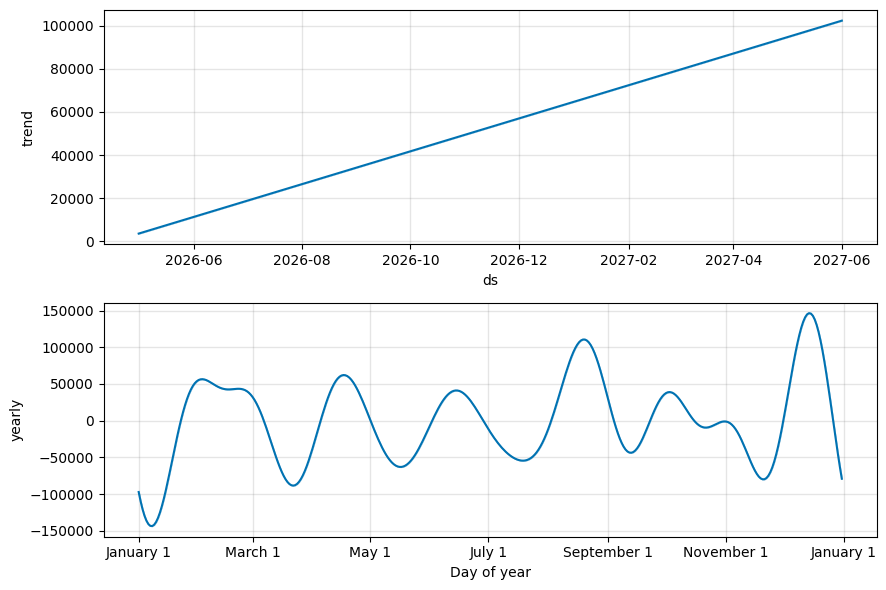

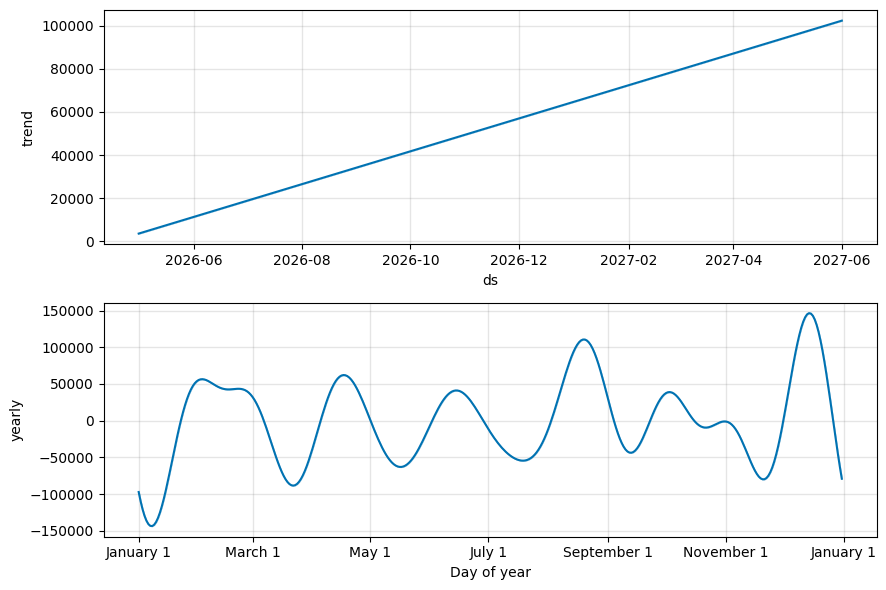

In [41]:
# Fonction : plot_forecast_components
# Input  : modèle Prophet entraîné, DataFrame de prévisions
# Output : figure des composantes (tendance + saisonnalité annuelle)
def plot_forecast_components(model, forecast):
    if model is not None:
        return model.plot_components(forecast)
    return px.line(forecast, x="ds", y="yhat", title="Tendance (fallback)")


plot_forecast_components(forecast_model, forecast)

---
## 8. Requête 4 — Analyse spatiale & Clustering
**Auteure : Chrisa**

### 8.1 Principe

On identifie les zones géographiques de Chicago où la criminalité se concentre
grâce à deux algorithmes de clustering appliqués aux coordonnées GPS.

### 8.2 Préparation géographique

Les lignes sans latitude ou longitude sont retirées. Les coordonnées sont filtrées
dans l'emprise de Chicago pour écarter les valeurs aberrantes.
Un **GeoDataFrame** est créé avec la projection `EPSG:4326`.

In [42]:
# Fonction : prepare_spatial_data
# Input  : DataFrame complet
# Output : DataFrame avec uniquement les observations géolocalisables dans Chicago
def prepare_spatial_data(df: pd.DataFrame) -> pd.DataFrame:
    spatial = df.dropna(subset=["Latitude", "Longitude"]).copy()
    return spatial[
        spatial["Latitude"].between(41.6, 42.1) &
        spatial["Longitude"].between(-87.9, -87.5)
    ].copy()


# Fonction : create_geodataframe
# Input  : DataFrame spatial avec colonnes Latitude et Longitude
# Output : GeoDataFrame avec objets Point géoréférencés (EPSG:4326)
def create_geodataframe(spatial_df: pd.DataFrame) -> gpd.GeoDataFrame:
    geometry = [Point(lon, lat) for lon, lat in
                zip(spatial_df["Longitude"], spatial_df["Latitude"])]
    return gpd.GeoDataFrame(spatial_df.copy(), geometry=geometry, crs="EPSG:4326")


spatial_df = prepare_spatial_data(df)
geo_df     = create_geodataframe(spatial_df)
print(f"Observations géolocalisées : {len(spatial_df)}")
display(geo_df[["Primary Type", "Latitude", "Longitude", "geometry"]].head())

Observations géolocalisées : 9968


,Primary Type,Latitude,Longitude,geometry
0,BATTERY,41.862851,-87.715755,POINT (-87.71576 41.86285)
1,BATTERY,41.761902,-87.696627,POINT (-87.69663 41.7619)
2,MOTOR VEHICLE THEFT,41.755575,-87.649023,POINT (-87.64902 41.75557)
3,MOTOR VEHICLE THEFT,41.992917,-87.741493,POINT (-87.74149 41.99292)
4,OTHER OFFENSE,41.918975,-87.728331,POINT (-87.72833 41.91897)


### 8.3 Carte de densité

La carte de densité agrège visuellement les incidents proches.
Une zone plus intense correspond à une concentration plus importante de points.

**Interprétation :** les zones rouges identifient les quartiers de Chicago
où la criminalité est la plus concentrée.

In [43]:
# Fonction : plot_density_map
# Input  : DataFrame spatial avec colonnes Latitude et Longitude
# Output : carte de densité interactive Plotly
def plot_density_map(spatial_df: pd.DataFrame) -> go.Figure:
    fig = px.density_mapbox(
        spatial_df, lat="Latitude", lon="Longitude", radius=10,
        center={"lat": 41.85, "lon": -87.65}, zoom=10,
        mapbox_style="carto-positron",
        title="Densité spatiale des crimes à Chicago",
        color_continuous_scale="Reds"
    )
    fig.update_layout(height=600, margin={"r": 0, "t": 50, "l": 0, "b": 0})
    return fig


plot_density_map(spatial_df).show()

### 8.4 Clustering K-means

K-means divise les crimes en `k` zones géographiques en regroupant les points les plus proches.
On choisit **k=6** car Chicago est naturellement divisée en 6 grands secteurs.

**Interprétation :** chaque couleur représente une zone géographique.
Les zones avec le plus de points sont les secteurs les plus touchés.

**Limite :** K-means impose le nombre de groupes et force chaque incident dans une zone,
même les incidents isolés.

In [44]:
# Fonction : apply_kmeans
# Input  : DataFrame spatial, k = nombre de clusters
# Output : DataFrame avec colonne cluster_kmeans, modèle KMeans entraîné
def apply_kmeans(spatial_df: pd.DataFrame, k: int = 6):
    coords = spatial_df[["Latitude", "Longitude"]].to_numpy()
    model  = KMeans(n_clusters=k, random_state=42, n_init=10)
    result = spatial_df.copy()
    result["cluster_kmeans"] = model.fit_predict(coords).astype(str)
    print(f"K-means : {k} zones créées")
    print(result["cluster_kmeans"].value_counts().sort_index())
    return result, model


# Fonction : plot_kmeans_map
# Input  : DataFrame enrichi du cluster K-means
# Output : carte interactive colorée par cluster
def plot_kmeans_map(kmeans_df: pd.DataFrame) -> go.Figure:
    fig = px.scatter_mapbox(
        kmeans_df, lat="Latitude", lon="Longitude", color="cluster_kmeans",
        center={"lat": 41.85, "lon": -87.65}, zoom=10,
        mapbox_style="carto-positron",
        title="K-means — 6 zones de criminalité à Chicago",
        hover_data=["Primary Type", "Arrest"], opacity=0.6
    )
    fig.update_layout(height=600, margin={"r": 0, "t": 50, "l": 0, "b": 0})
    return fig


df_kmeans, kmeans_model = apply_kmeans(spatial_df, k=6)
plot_kmeans_map(df_kmeans).show()

K-means : 6 zones créées
cluster_kmeans
0    1254
1    1857
2    2329
3    2197
4    1377
5     954
Name: count, dtype: int64


### 8.5 Clustering OPTICS

Contrairement à K-means, OPTICS détecte automatiquement les zones denses
sans qu'on fixe le nombre de clusters à l'avance.
Les crimes isolés sont étiquetés **-1** (bruit).

**Paramètres :**
- `min_samples=20` : minimum 20 crimes proches pour former une zone dense
- `xi=0.05` : sensibilité pour séparer les zones

**Interprétation :** les zones colorées sont les vrais hotspots denses.
Les points -1 sont des crimes géographiquement isolés.

In [45]:
# Fonction : apply_optics
# Input  : DataFrame spatial, min_samples = densité minimale par zone
# Output : DataFrame avec colonne cluster_optics (-1 = bruit), modèle OPTICS
def apply_optics(spatial_df: pd.DataFrame, min_samples: int = 20, xi: float = 0.05):
    coords = spatial_df[["Latitude", "Longitude"]].to_numpy()
    model  = OPTICS(min_samples=min_samples, xi=xi, min_cluster_size=0.05)
    result = spatial_df.copy()
    result["cluster_optics"] = model.fit_predict(coords).astype(str)
    nb_zones = result["cluster_optics"].nunique() - 1
    nb_bruit = (result["cluster_optics"] == "-1").sum()
    print(f"OPTICS : {nb_zones} zones denses | {nb_bruit} crimes isolés ({nb_bruit/len(result)*100:.1f}%)")
    return result, model


# Fonction : plot_optics_map
# Input  : DataFrame enrichi du cluster OPTICS
# Output : carte interactive des zones denses et du bruit
def plot_optics_map(optics_df: pd.DataFrame) -> go.Figure:
    fig = px.scatter_mapbox(
        optics_df, lat="Latitude", lon="Longitude", color="cluster_optics",
        center={"lat": 41.85, "lon": -87.65}, zoom=10,
        mapbox_style="carto-positron",
        title="OPTICS — Zones denses de criminalité à Chicago (−1 = crime isolé)",
        hover_data=["Primary Type", "Arrest"], opacity=0.6
    )
    fig.update_layout(height=600, margin={"r": 0, "t": 50, "l": 0, "b": 0})
    return fig


df_optics, optics_model = apply_optics(spatial_df)
plot_optics_map(df_optics).show()

OPTICS : 0 zones denses | 0 crimes isolés (0.0%)


### 8.6 Composition des types de crimes par zone K-means

On enrichit le clustering K-means en regardant quels types de crimes dominent
dans chaque zone géographique.

**Interprétation :** ce graphique permet de voir si certaines zones ont
un profil criminel particulier.

In [46]:
# Fonction : plot_crime_types_by_cluster
# Input  : DataFrame avec colonne cluster_kmeans
# Output : graphique barres empilées — types de crimes par zone
def plot_crime_types_by_cluster(kmeans_df: pd.DataFrame) -> go.Figure:
    group = (
        kmeans_df.groupby(["cluster_kmeans", "Primary Type"], observed=True)
        .size()
        .reset_index(name="Nombre_incidents")
    )
    fig = px.bar(
        group, x="cluster_kmeans", y="Nombre_incidents", color="Primary Type",
        barmode="stack",
        title="Composition des types de crimes par cluster K-means",
        labels={"cluster_kmeans": "Cluster", "Nombre_incidents": "Nombre d'incidents",
                "Primary Type": "Type de crime"}
    )
    return fig


plot_crime_types_by_cluster(df_kmeans).show()

---
## 9. Intégration du dashboard

Le dashboard est un livrable distinct du notebook.
Il organise les résultats des quatre requêtes et doit être lancé depuis la racine du projet avec :

```bash
python dashboard/app.py
```

Le navigateur doit ensuite ouvrir : `http://127.0.0.1:8050`

In [47]:
# Fonction : launch_dashboard
# Input  : racine du projet, start_server = True pour démarrer Dash
# Output : chemin du fichier app.py ou processus serveur
def launch_dashboard(project_root: Path, start_server: bool = False):
    app_path = project_root / "dashboard" / "app.py"
    if not app_path.exists():
        print("Dashboard non trouvé. Ajoutez dashboard/app.py avant la remise finale.")
        return None
    if start_server:
        return subprocess.run([sys.executable, str(app_path)], check=True)
    print(f"Dashboard détecté : {app_path}")
    print("Commande de lancement : python dashboard/app.py")
    return app_path


PROJECT_ROOT     = resolve_project_root()
START_DASHBOARD  = False  # passer à True pendant la démo pour démarrer Dash
launch_dashboard(PROJECT_ROOT, start_server=START_DASHBOARD)

Dashboard détecté : /Users/chrisamendoza/Desktop/ESILV/M1/S2/Data Analysis/TD/PROJECT/chicago-crime-analysis/dashboard/app.py
Commande de lancement : python dashboard/app.py


PosixPath('/Users/chrisamendoza/Desktop/ESILV/M1/S2/Data Analysis/TD/PROJECT/chicago-crime-analysis/dashboard/app.py')

---
## 10. Synthèse générale des résultats

Les résultats produits par le notebook permettent de retenir les éléments suivants :

1. Le dataset contient **10 000 crimes récents** couvrant l'ensemble de la ville de Chicago.
2. Les types de crimes les plus fréquents et les taux d'arrestation varient fortement selon la catégorie.
3. L'algorithme Apriori révèle des associations significatives entre le lieu, l'heure et la probabilité d'arrestation.
4. L'analyse temporelle montre une tendance et une saisonnalité — Prophet permet d'anticiper l'évolution sur 12 mois.
5. La criminalité n'est pas uniformément répartie sur Chicago — K-means et OPTICS identifient des hotspots précis.

## 11. Limites et précautions d'interprétation

- Le dataset est limité à 10 000 crimes récents et n'est pas exhaustif.
- Les incidents enregistrés dépendent des pratiques de signalement de la police.
- L'année 2026 est incomplète dans les données.
- Les règles Apriori décrivent des associations, pas des causes.
- Les paramètres de K-means et d'OPTICS influencent les clusters obtenus.
- Les prévisions reposent sur l'historique disponible et restent incertaines.

## 12. Commandes finales pour la démonstration

Depuis la racine du dépôt :

```bash
python -m pip install -r dashboard/requirements.txt
jupyter notebook notebooks/notebook_final.ipynb
```

Dans un second terminal :

```bash
python dashboard/app.py
```